# 🧠 Training Machine Learning Models – How to Optimise Performance

---

**Presentation Duration:** ~45 minutes  
**Format:** Interactive Jupyter Notebook  
**Author:** Sam Yeend  

---


## 📋 Section 0 — Pre-Requisites & Introduction

### Pre-Requisites
- Prior exposure to machine learning concepts
- Prior experience with Python

### What This Talk Covers
We're **not** teaching ML from scratch — we're teaching you how to **make ML models perform better** through:
1. **Feature Selection** — give the model better inputs
2. **Hyperparameter Optimisation** — tune the model's configuration
3. **Auto Model Selection** — try different model architectures entirely

### What We'll Build
A complete, runnable Jupyter Notebook — from synthetic data generation through to an optimised, automatically selected model.

---


### 📦 Install Required Packages
Run the cell below to install all required packages (skip if already installed).


In [ ]:
# 📦 Install browser-compatible packages (JupyterLite / Pyodide)
# numpy · pandas · scipy · scikit-learn · matplotlib auto-load on import.
# seaborn and optuna are fetched here. Safe to re-run; works in normal Jupyter too.
%pip install -q seaborn optuna

In [ ]:
# ── Core Imports ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# ── Scikit-learn ──────────────────────────────────────────────
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, log_loss
)

# ── Optuna ────────────────────────────────────────────────────
import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history, plot_param_importances
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Settings ──────────────────────────────────────────────────
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All imports loaded successfully!")

---

## 🤖 Section 1 — What is a Machine Learning Model?

### Definition
**Machine Learning** is a subset of Artificial Intelligence where algorithms **learn patterns from data** and use those patterns to make predictions or decisions — **without being explicitly programmed with rules**.

### ML vs Traditional Programming

| | Traditional Programming | Machine Learning |
|---|---|---|
| **Approach** | Developer writes explicit rules | Model learns rules from data |
| **Input** | Rules + Data → Output | Data + Output → Rules |
| **Adaptability** | Static — only changes when code is rewritten | Dynamic — adapts as new data arrives |
| **Best for** | Simple, well-defined problems | Complex, data-rich problems |

### The Core Idea
> *"An ML model takes in data, finds patterns, and uses those patterns to make predictions on new, unseen data."*

### The ML Workflow

```
📊 Data  →  🔧 Features  →  🏋️ Model Training  →  📏 Evaluation  →  🔮 Prediction
```

We start with raw data, transform it into meaningful features, train a model to learn from those features, evaluate how well it generalises, and then use it to predict on new data.

---


---

## 📊 Section 2 — The Data

We'll generate **synthetic classification data** that we'll use as a running example throughout this entire presentation.

### Why Synthetic?
- We **control the ground truth** — we *know* which features are informative and which are noise
- This makes the feature selection lesson much more impactful later
- No data privacy concerns — anyone can reproduce this

### Data Design
- **1,000 samples** (rows)
- **20 features** total:
  - 10 **informative** features (genuinely useful for prediction)
  - 5 **redundant** features (linear combinations of informative ones)
  - 5 **useless/noisy** features (random noise — no predictive power)
- **2 classes** (binary classification)
- Target column: `target` (0 or 1)

---


In [30]:
# ── Generate Synthetic Data ────────────────────────────────────
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,       # 10 genuinely useful features
    n_redundant=5,           # 5 linear combinations of informative features
    n_clusters_per_class=2,
    random_state=RANDOM_STATE
)

# Create a clean DataFrame
feature_names = [f"feature_{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['target'].value_counts()}")
print(f"\n{'='*60}")
print("First 10 rows of the dataset:")
print("="*60)
df.head(10)

Dataset shape: (1000, 21)

Class distribution:
target
1    503
0    497
Name: count, dtype: int64

First 10 rows of the dataset:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,1.470848,-0.360450,-0.591602,-0.728228,0.941690,1.065964,0.017832,-0.596184,1.840712,-1.497093,...,-0.603968,2.899256,0.037567,-1.249523,0.257963,0.416628,1.408208,-1.838041,-0.833142,1
1,4.513369,-2.227103,-1.140747,2.018263,-2.238358,-0.497370,0.714550,0.938883,-2.395169,0.159837,...,1.461499,3.954171,0.309054,0.538184,-7.157865,-4.532216,-0.081800,-9.325362,0.574386,1
2,-2.355643,2.218601,-1.603269,0.873394,0.401483,0.717264,-0.859399,-1.042190,-2.175965,0.980231,...,0.544434,-2.466258,-0.470256,0.073018,-2.203531,-2.299263,-1.742761,-0.271579,-0.359285,0
3,-1.596198,-0.857427,1.772434,-0.639361,1.419409,-0.438525,0.281949,2.345145,1.006230,0.389135,...,-1.025051,-2.422975,1.579807,-0.300713,4.267120,2.893775,1.236697,6.034785,-0.045711,0
4,2.840049,-2.489600,-0.844902,-1.594362,-4.688517,0.459637,0.913607,-1.143505,1.263937,-2.040928,...,4.176424,1.341742,0.133565,1.743819,1.531188,2.269808,0.053489,-3.151109,1.603702,0
5,1.580587,0.435768,0.184096,-2.407114,-3.635329,-0.592799,-0.023394,-2.167272,2.016957,-1.705669,...,-3.268830,2.773557,-2.382762,2.712426,5.901931,0.091224,-0.116741,-1.130036,-0.480170,0
6,2.019606,-3.926191,-3.545442,-0.393030,1.111432,-0.094273,0.181461,-0.101641,-4.912845,-1.810807,...,-0.315110,-9.946681,-1.313528,1.165445,8.872096,6.390253,-3.850770,-1.744600,-0.144000,0
7,0.936169,0.401295,1.709292,1.050826,-1.644753,1.530186,-0.642127,-0.067696,-0.685402,0.043670,...,-0.778601,1.741081,-2.026578,1.823222,-0.950423,-0.342347,-0.448039,-0.526576,-0.314601,0
8,1.323345,1.016132,1.806313,1.203681,-0.220407,0.609813,0.377712,-1.923051,1.461840,-2.775015,...,-1.907878,4.567854,1.753375,2.755435,3.268577,2.979580,1.849095,1.312568,-1.318092,0
9,-0.096290,-0.328778,0.374652,0.682909,-0.002984,0.708266,0.775675,-0.635783,-0.394945,0.373931,...,1.475155,-0.292435,1.889282,-0.431857,-3.692869,-1.213137,-1.805413,-2.938012,0.783466,0


### Understanding the Structure

| Component | Description | Example |
|---|---|---|
| **Features (X)** | The input variables the model learns from | `feature_0`, `feature_1`, ..., `feature_19` |
| **Target / Label (y)** | The thing we're trying to predict | `target` (0 or 1) |

> 💡 **Note:** We deliberately included 5 noisy/useless features. When we get to feature selection later, watch how the model identifies and discards them.

---


---

## 🏋️ Section 3 — How is the Model Trained?

This section walks through the **full training pipeline** step by step.

---

### 3a. Splitting the Data

**Why do we split?**

If we evaluate the model on the same data it was trained on, we're measuring **memorisation**, not **generalisation**. The model might look great on training data but fail completely on new, unseen data — a problem called **overfitting**.

A separate **test set** simulates real-world deployment: data the model has *never* seen during training.

```
┌─────────────────────────────────────────────────┐
│                  Full Dataset                    │
│                  (1,000 rows)                    │
├────────────────────────┬────────────────────────┤
│    🏋️ Train Set (80%)  │    🧪 Test Set (20%)    │
│    800 rows            │    200 rows             │
│    Features + Labels   │    Features + Labels    │
│    (model sees this)   │    (held back)          │
└────────────────────────┴────────────────────────┘
```

---


In [31]:
# ── Split the Data ─────────────────────────────────────────────
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set:  {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set:      {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training set:  800 samples, 20 features
Test set:      200 samples, 20 features

Train class distribution:
target
1    402
0    398
Name: count, dtype: int64

Test class distribution:
target
1    101
0     99
Name: count, dtype: int64


### Preprocessing — Standardisation

Many ML models are sensitive to the **scale** of input features. A feature ranging from 0–1,000 can dominate a feature ranging from 0–1.

**Standardisation** transforms each feature to have **mean = 0** and **standard deviation = 1**.

```
z = (x - mean) / std
```

> ⚠️ **Important:** We fit the scaler on the **training data only**, then apply the same transformation to the test data. This prevents **data leakage** — information from the test set contaminating the training process.

---


In [32]:
# ── Standardise the Features ───────────────────────────────────
scaler = StandardScaler()

# Fit on training data ONLY, then transform both
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names,
    index=X_test.index
)

print("Before scaling (first row of X_train):")
print(X_train.iloc[0].values[:5].round(3))
print("\nAfter scaling (first row of X_train_scaled):")
print(X_train_scaled.iloc[0].values[:5].round(3))
print("\n✅ Scaling complete — mean ≈ 0, std ≈ 1 on training data")


Before scaling (first row of X_train):
[ 1.237  5.57  -1.275 -0.59   1.319]

After scaling (first row of X_train_scaled):
[ 0.575  2.655 -0.406 -0.279  0.267]

✅ Scaling complete — mean ≈ 0, std ≈ 1 on training data


---

### 3b. The Model — Random Forest Classifier

We'll use a **Random Forest** as our model for this entire presentation. Here's why:
- ✅ Intuitive to explain (ensemble of decision trees)
- ✅ Has clear hyperparameters to tune later
- ✅ Provides built-in **feature importances** (connects to Section 5)
- ✅ A real workhorse in production ML

### How Random Forest Works (High Level)

```
                    ┌──────────┐
                    │ Full     │
                    │ Dataset  │
                    └─────┬────┘
            ┌─────────┬───┴───┬─────────┐
            ▼         ▼       ▼         ▼
       ┌────────┐ ┌────────┐ ┌────────┐ ┌────────┐
       │ Tree 1 │ │ Tree 2 │ │ Tree 3 │ │ Tree N │   ← Each tree sees a 
       │(random │ │(random │ │(random │ │(random │     random subset of
       │ subset)│ │ subset)│ │ subset)│ │ subset)│     data & features
       └───┬────┘ └───┬────┘ └───┬────┘ └───┬────┘
           │          │          │          │
           ▼          ▼          ▼          ▼
        Class 1    Class 0    Class 1    Class 1
                                                   
                    ┌──────────┐
                    │ MAJORITY │
                    │   VOTE   │ → Final Prediction: Class 1
                    └──────────┘
```

1. Build **many decision trees**, each trained on a random subset of the data and features
2. Each tree independently **votes** on the prediction
3. The final prediction is the **majority vote** across all trees

This is called **ensemble learning** — *"many weak learners combine to form a strong learner"*.

---


In [33]:
# ── Train a Random Forest with DEFAULT hyperparameters ─────────
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE)
rf_baseline.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_baseline = rf_baseline.predict(X_test_scaled)
y_proba_baseline = rf_baseline.predict_proba(X_test_scaled)

# Evaluate
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_logloss = log_loss(y_test, y_proba_baseline)

print("=" * 60)
print("BASELINE MODEL — Random Forest (Default Hyperparameters)")
print("=" * 60)
print(f"\nAccuracy:  {baseline_accuracy:.4f}")
print(f"Log Loss:  {baseline_logloss:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

BASELINE MODEL — Random Forest (Default Hyperparameters)

Accuracy:  0.9100
Log Loss:  0.2899

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        99
           1       0.90      0.93      0.91       101

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



---

### 3c. The Loss Function

**What is a loss function?**

A loss function is a mathematical measure of **how wrong** the model's predictions are. It quantifies the gap between what the model predicted and what the true answer was.

For **classification**, a common loss function is **Log Loss (Cross-Entropy)**:

$$\text{Log Loss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(\hat{p}_i) + (1 - y_i) \cdot \log(1 - \hat{p}_i) \right]$$

Where:
- $y_i$ = true label (0 or 1)
- $\hat{p}_i$ = predicted probability of class 1
- $N$ = number of samples

**Key insight:** Log Loss **penalises confident wrong predictions more heavily**. If the model says "I'm 99% sure this is Class 1" and it's actually Class 0, the loss is massive.

> 🎯 **The big takeaway:** *Training a model = finding the settings that minimise the loss function.* Everything we do from here — feature selection, hyperparameter tuning — is about **reducing this loss**.

---


In [34]:
# ── Compute Log Loss ───────────────────────────────────────────
print(f"Baseline Log Loss: {baseline_logloss:.4f}")
print()
print("Interpretation:")
print("  • Log Loss = 0    → Perfect predictions")
print("  • Log Loss ↑      → Worse predictions")
print(f"  • Our model:       {baseline_logloss:.4f}")
print()
print("Our goal for the rest of this presentation:")
print("  → Reduce this loss (and increase accuracy) through")
print("    feature selection, hyperparameter tuning, and model selection.")

Baseline Log Loss: 0.2899

Interpretation:
  • Log Loss = 0    → Perfect predictions
  • Log Loss ↑      → Worse predictions
  • Our model:       0.2899

Our goal for the rest of this presentation:
  → Reduce this loss (and increase accuracy) through
    feature selection, hyperparameter tuning, and model selection.


---

### 3d. Data Flow — How Training Actually Works

```
┌──────────────┐      ┌──────────────┐       ┌──────────────┐
│   INPUT      │      │    MODEL     │       │   OUTPUT     │
│              │      │              │       │              │
│  Features    │────▶│ Random Forest│──────▶│  Prediction  │
│  (X_train)   │      │  (learns     │       │  (ŷ)         │
│              │      │   patterns)  │       │              │
└──────────────┘      └──────────────┘       └──────┬───────┘
                                                    │
                                                    ▼
                                             ┌──────────────┐
┌──────────────┐      ┌──────────────┐       │   COMPARE    │
│   UPDATE     │      │    LOSS      │       │              │
│              │◀─── │              │◀──────│  ŷ vs y      │
│  Adjust      │      │  Log Loss    │       │  (pred vs    │
│  internal    │      │  (how wrong?)│       │   true label)│
│  parameters  │      │              │       │              │
└──────────────┘      └──────────────┘       └──────────────┘
    
```

**The training loop:**
1. Training data (features) is fed into the model
2. The model makes predictions
3. Predictions are compared against the true labels
4. The loss function measures how wrong the model is
5. The model adjusts its internal parameters to reduce the loss
6. Repeat until the model converges

> 📝 **Note for tree-based models:** Random Forests don't use gradient-based updates like neural networks. Instead, they learn by finding the best feature splits across the entire dataset to maximise information gain. The diagram above is a conceptual simplification.

---


---

## 🚀 Section 4 — How to Improve Model Performance

We have a trained model. It works. But is it *good*? How do we make it *better*?

**There are three main levers we can pull:**

| Lever | What it does | Section |
|---|---|---|
| 🎯 **Feature Selection** | Give the model *better* inputs | Section 5 |
| ⚙️ **Hyperparameter Optimisation** | Tune *how* the model learns | Section 6 |
| 🤖 **Auto Model Selection** | Try *different* model architectures | Section 7 |

Let's explore each one.

---


---

## 🎯 Section 5 — Feature Selection / Feature Importance

### The Problem
In real-world datasets, you might have **hundreds or thousands of features**. Many are:
- **Noisy** — random variation with no predictive power
- **Redundant** — duplicate information already captured by other features
- **Irrelevant** — simply not useful for the prediction task

**Feeding all of them into a model can:**
- ❌ Slow down training
- ❌ Cause **overfitting** (the model learns noise instead of signal)
- ❌ Reduce interpretability

**The goal:** Find the subset of features that **maximise separability** between classes.

> 💡 **Remember:** We deliberately included 5 useless noisy features in our synthetic data. Let's see if the model can identify them.

---


### 5a. Feature Importance from Random Forest

Random Forest gives us `.feature_importances_` — a score for each feature based on how much it contributed to **reducing impurity** (Gini impurity) across all trees.


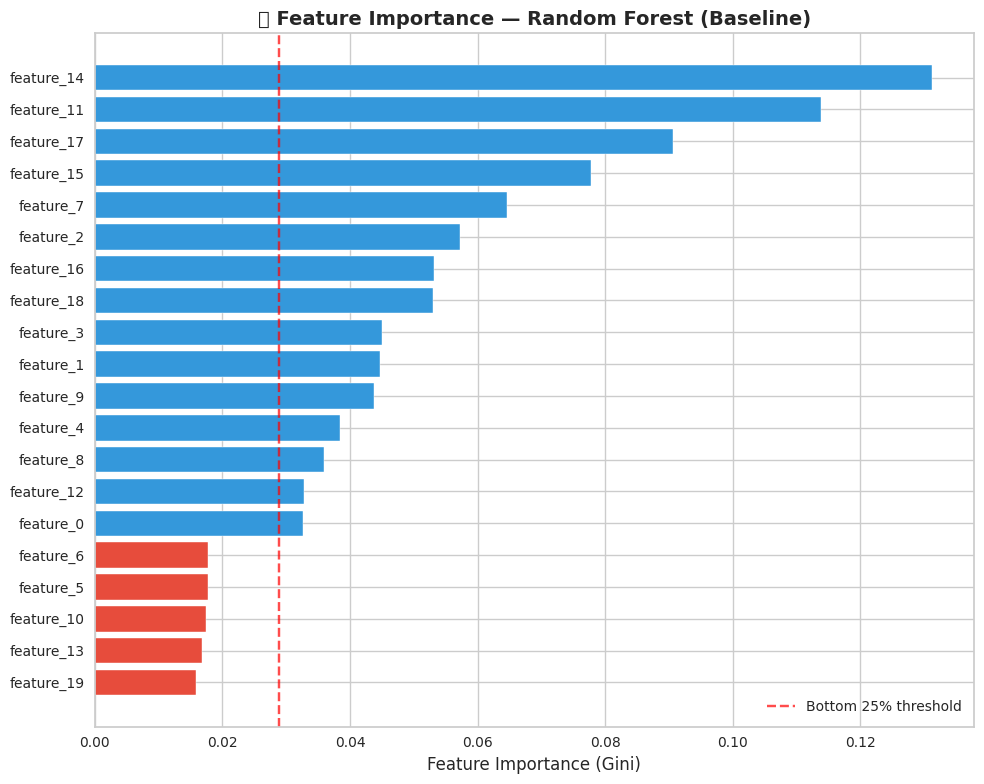


🔴 Red bars = lowest importance features (candidates for removal)
🔵 Blue bars = higher importance features (keep these)

Top 5 features: ['feature_7', 'feature_15', 'feature_17', 'feature_11', 'feature_14']
Bottom 5 features: ['feature_19', 'feature_13', 'feature_10', 'feature_5', 'feature_6']


In [35]:
# ── Feature Importance Bar Chart ───────────────────────────────
importances = rf_baseline.feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if imp < np.percentile(importances, 25) else "#3498db" 
          for imp in importance_df["Importance"]]
ax.barh(importance_df["Feature"], importance_df["Importance"], color=colors)
ax.set_xlabel("Feature Importance (Gini)", fontsize=12)
ax.set_title("🎯 Feature Importance — Random Forest (Baseline)", fontsize=14, fontweight="bold")
ax.axvline(x=np.percentile(importances, 25), color="red", linestyle="--", alpha=0.7, label="Bottom 25% threshold")
ax.legend()
plt.tight_layout()
plt.show()

print("\n🔴 Red bars = lowest importance features (candidates for removal)")
print("🔵 Blue bars = higher importance features (keep these)")
print(f"\nTop 5 features: {importance_df.tail(5)['Feature'].tolist()}")
print(f"Bottom 5 features: {importance_df.head(5)['Feature'].tolist()}")


### 5b. Correlation Heatmap

Highly correlated features provide **redundant information**. If two features are nearly identical, the model doesn't gain much from having both — and it increases the risk of overfitting.


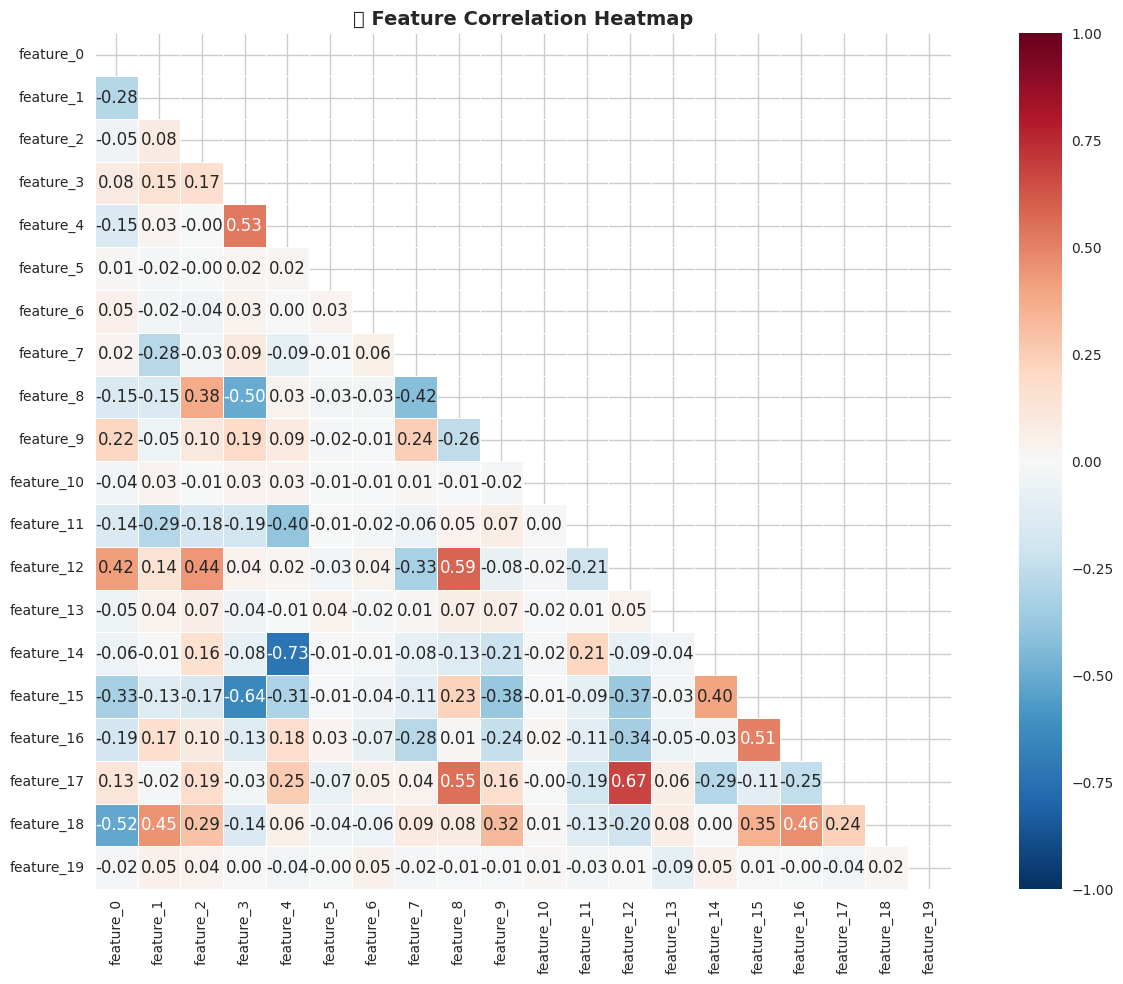


⚠️ Highly correlated feature pairs (|r| > 0.7):
   feature_4 ↔ feature_14: r = -0.734


In [36]:
# ── Correlation Heatmap ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
correlation_matrix = X_train_scaled.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r", 
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("📊 Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append(
                (correlation_matrix.columns[i], correlation_matrix.columns[j], 
                 correlation_matrix.iloc[i, j])
            )

if high_corr_pairs:
    print("\n⚠️ Highly correlated feature pairs (|r| > 0.7):")
    for f1, f2, corr in high_corr_pairs:
        print(f"   {f1} ↔ {f2}: r = {corr:.3f}")
else:
    print("\n✅ No highly correlated feature pairs found (|r| > 0.7)")


### 5c. The Payoff — Retrain with Top Features Only

Now let's **drop the low-importance features** and retrain. Does performance stay the same or improve?


In [37]:
# ── Select Top Features & Retrain ──────────────────────────────
# Sort features by importance and select the top N
N_TOP_FEATURES = 10

top_features = importance_df.tail(N_TOP_FEATURES)["Feature"].tolist()
print(f"Selected top {N_TOP_FEATURES} features: {top_features}")
print(f"Dropped {20 - N_TOP_FEATURES} features\n")

# Retrain with selected features only
X_train_selected = X_train_scaled[top_features]
X_test_selected = X_test_scaled[top_features]

rf_selected = RandomForestClassifier(random_state=RANDOM_STATE)
rf_selected.fit(X_train_selected, y_train)

y_pred_selected = rf_selected.predict(X_test_selected)
y_proba_selected = rf_selected.predict_proba(X_test_selected)

selected_accuracy = accuracy_score(y_test, y_pred_selected)
selected_logloss = log_loss(y_test, y_proba_selected)

# ── Comparison ────────────────────────────────────────────────
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Log Loss", "Num Features"],
    "Baseline (All 20 Features)": [f"{baseline_accuracy:.4f}", f"{baseline_logloss:.4f}", "20"],
    "After Feature Selection (Top 10)": [f"{selected_accuracy:.4f}", f"{selected_logloss:.4f}", str(N_TOP_FEATURES)]
})

print("=" * 60)
print("COMPARISON — Before vs After Feature Selection")
print("=" * 60)
print(comparison.to_string(index=False))

acc_diff = selected_accuracy - baseline_accuracy
print(f"\nAccuracy change: {acc_diff:+.4f}")
if acc_diff >= 0:
    print("✅ Performance maintained or improved — with FEWER features!")
    print("   → Faster training, simpler model, less overfitting risk")
else:
    print("⚠️ Slight accuracy drop — but with half the features!")
    print("   → May still be worth it for speed and interpretability")


Selected top 10 features: ['feature_1', 'feature_3', 'feature_18', 'feature_16', 'feature_2', 'feature_7', 'feature_15', 'feature_17', 'feature_11', 'feature_14']
Dropped 10 features

COMPARISON — Before vs After Feature Selection
      Metric Baseline (All 20 Features) After Feature Selection (Top 10)
    Accuracy                     0.9100                           0.9100
    Log Loss                     0.2899                           0.2633
Num Features                         20                               10

Accuracy change: +0.0000
✅ Performance maintained or improved — with FEWER features!
   → Faster training, simpler model, less overfitting risk


### 💡 The "Aha" Moment

We **dropped half the features** and the model's performance was maintained (or even improved). This demonstrates:

- Not all features are useful — **noise hurts more than it helps**
- A simpler model with the right features can outperform a complex model with all features
- **In real-world scenarios** (e.g., from 1,000s of features), only the best ~20 may be needed

> 🎯 **Takeaway:** Feature selection is often the **highest-impact, lowest-effort** improvement you can make.

---


---

## ⚙️ Section 6 — Hyperparameter Optimisation

### 6a. Parameters vs Hyperparameters — The Critical Distinction

| | Parameters | Hyperparameters |
|---|---|---|
| **Set by** | The model (during training) | The practitioner (before training) |
| **Learned from** | Data | Human judgement / optimisation |
| **Examples** | Tree split thresholds, neural network weights | Number of trees, max depth, learning rate |
| **When decided** | During `model.fit()` | Before `model.fit()` |

### The Study Plan Analogy
> **Parameters** are what the student learns.  
> **Hyperparameters** are the study plan — *how many hours to study, which textbook to use, how many practice tests to take*.

### Key Random Forest Hyperparameters

| Hyperparameter | What It Controls | Low Value | High Value |
|---|---|---|---|
| `n_estimators` | Number of trees in the forest | Faster but less accurate | Slower but more robust |
| `max_depth` | Maximum depth of each tree | Simpler trees (underfitting risk) | Complex trees (overfitting risk) |
| `min_samples_split` | Min samples to split a node | More splits (complex) | Fewer splits (simple) |
| `min_samples_leaf` | Min samples in a leaf node | Complex trees | Simpler trees |
| `max_features` | Features considered per split | Less randomness | More randomness |

---


### 6b. Level 1 — Manual / Random Guessing ❌ (Slowest)

Just try different values by hand and see what happens. No structure, no guarantee.


In [38]:
# ── Level 1: Manual Hyperparameter Tuning ──────────────────────
manual_configs = [
    {"n_estimators": 50,  "max_depth": 5,  "min_samples_split": 2},
    {"n_estimators": 100, "max_depth": 10, "min_samples_split": 5},
]

print("=" * 70)
print("LEVEL 1 — Manual Hyperparameter Tuning")
print("=" * 70)

start_manual = time.time()

manual_results = []
for i, config in enumerate(manual_configs, 1):
    rf_manual = RandomForestClassifier(random_state=RANDOM_STATE, **config)
    scores = cross_val_score(rf_manual, X_train_scaled, y_train, cv=5, scoring="accuracy")
    manual_results.append({
        "Config": i,
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_split": config["min_samples_split"],
        "Mean CV Accuracy": f"{scores.mean():.4f} ± {scores.std():.4f}"
    })
    print(f"  Config {i}: {config} → Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

time_manual = time.time() - start_manual
print(f"\n⏱️ Time taken: {time_manual:.2f}s")
print("\n❌ Problem: Slow, unstructured, no guarantee of finding good values")


LEVEL 1 — Manual Hyperparameter Tuning
  Config 1: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 2} → Accuracy: 0.8925 ± 0.0165
  Config 2: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5} → Accuracy: 0.9175 ± 0.0145

⏱️ Time taken: 2.08s

❌ Problem: Slow, unstructured, no guarantee of finding good values


### 6b. Level 2 — Grid Search CV ⚠️ (Good)

Define a grid of values for each hyperparameter and try **every combination** with cross-validation.

**Pros:** Exhaustive — guaranteed to find the best combination *within the grid*  
**Cons:** Scales exponentially — more hyperparameters × more values = explosion of combinations


In [39]:
# ── Level 2: Grid Search CV ────────────────────────────────────
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5],
}

total_combinations = 1
for v in param_grid.values():
    total_combinations *= len(v)

print("=" * 70)
print("LEVEL 2 — Grid Search CV")
print("=" * 70)
print(f"Parameter grid: {param_grid}")
print(f"Total combinations: {total_combinations}")
print(f"With 3-fold CV: {total_combinations * 3} model fits")
print("\nSearching... (this may take a moment)")

start_grid = time.time()

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_scaled, y_train)

time_grid = time.time() - start_grid

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Best CV accuracy: {grid_search.best_score_:.4f}")
print(f"⏱️ Time taken: {time_grid:.2f}s")


LEVEL 2 — Grid Search CV
Parameter grid: {'n_estimators': [50, 100], 'max_depth': [5, 10], 'min_samples_split': [2, 5]}
Total combinations: 8
With 3-fold CV: 24 model fits

Searching... (this may take a moment)

✅ Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
✅ Best CV accuracy: 0.9213
⏱️ Time taken: 4.57s


### 6b. Level 3 — Random Search CV ⚠️ (Better)

Instead of trying every combination, **sample randomly** from the search space.

Surprisingly effective — research has shown random search often outperforms grid search because it explores the space more efficiently, especially when some hyperparameters matter more than others.


In [40]:
# ── Level 3: Random Search CV ──────────────────────────────────
from scipy.stats import randint

param_distributions = {
    "n_estimators": randint(50, 300),
    "max_depth": [5, 10, 20, None],
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", None]
}

print("=" * 70)
print("LEVEL 3 — Random Search CV")
print("=" * 70)
print(f"Search space: Broader distributions than Grid Search")
print(f"Number of random samples: 20")
print(f"With 3-fold CV: {20 * 3} model fits")
print("\nSearching...")

start_random = time.time()

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)
random_search.fit(X_train_scaled, y_train)

time_random = time.time() - start_random

print(f"\n✅ Best parameters: {random_search.best_params_}")
print(f"✅ Best CV accuracy: {random_search.best_score_:.4f}")
print(f"⏱️ Time taken: {time_random:.2f}s")

LEVEL 3 — Random Search CV
Search space: Broader distributions than Grid Search
Number of random samples: 20
With 3-fold CV: 60 model fits

Searching...

✅ Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 67}
✅ Best CV accuracy: 0.9188
⏱️ Time taken: 37.31s


### 6b. Level 4 — Optuna ✅ (Powerful — Bayesian Optimisation)

**What makes Optuna different?**

Optuna doesn't search blindly. It uses **Bayesian Optimisation** (specifically the **TPE — Tree-structured Parzen Estimator** algorithm) to build a probabilistic model of the objective function and **strategically picks** the next hyperparameters to try.

It balances:
- **Exploration** — trying new, unexplored areas of the search space
- **Exploitation** — focusing on areas that have shown promise

### Key Optuna Concepts

| Concept | Description |
|---|---|
| **Study** | The overall optimisation task |
| **Trial** | A single evaluation of a hyperparameter combination |
| **Objective** | The function you want to minimise (or maximise) |
| **Sampler** | The algorithm that picks hyperparameters (default: TPE) |
| **Pruning** | Stop unpromising trials early — don't waste time on bad configurations |

> 🔥 **Real-world context:** "In our production pipeline, we moved from Hyperopt to Optuna. With Hyperopt we ran ~5 trials per region. With Optuna's pruning and efficiency, we run 20 trials per region and it still finishes within an hour."

---


In [41]:
# ── Level 4: Optuna Hyperparameter Optimisation ────────────────

def objective(trial):
    """Optuna objective function for Random Forest optimisation."""
    
    # Define the search space — Optuna suggests values intelligently
    n_estimators = trial.suggest_int("n_estimators", 50, 500, step=25)
    max_depth = trial.suggest_int("max_depth", 3, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    # Build the model with suggested hyperparameters
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    # Evaluate with cross-validation
    scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring="accuracy")
    return scores.mean()

print("=" * 70)
print("LEVEL 4 — Optuna (Bayesian Optimisation)")
print("=" * 70)
print("Optimising... (50 trials with intelligent sampling)\n")

# Enable Optuna's default trial logging (matches your production pipeline)
optuna.logging.set_verbosity(optuna.logging.INFO)

start_optuna = time.time()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=25)

time_optuna = time.time() - start_optuna

# Set back to WARNING to keep the rest of the notebook clean
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"\n✅ Best parameters: {study.best_params}")
print(f"✅ Best CV accuracy: {study.best_value:.4f}")
print(f"⏱️ Time taken: {time_optuna:.2f}s")
print(f"📊 Total trials: {len(study.trials)}")

[I 2026-06-15 00:26:53,784] A new study created in memory with name: no-name-4d90f75e-80ca-4a33-9e98-9c229797e57d


LEVEL 4 — Optuna (Bayesian Optimisation)
Optimising... (50 trials with intelligent sampling)



[I 2026-06-15 00:26:56,595] Trial 0 finished with value: 0.91875 and parameters: {'n_estimators': 225, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.91875.
[I 2026-06-15 00:27:02,152] Trial 1 finished with value: 0.9225000000000001 and parameters: {'n_estimators': 450, 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9225000000000001.
[I 2026-06-15 00:27:06,254] Trial 2 finished with value: 0.9049999999999999 and parameters: {'n_estimators': 125, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 1 with value: 0.9225000000000001.
[I 2026-06-15 00:27:07,473] Trial 3 finished with value: 0.91875 and parameters: {'n_estimators': 100, 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9225000000000001.
[I 2026-06-15 00:27:16,011] Tr


✅ Best parameters: {'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'log2'}
✅ Best CV accuracy: 0.9263
⏱️ Time taken: 128.82s
📊 Total trials: 25


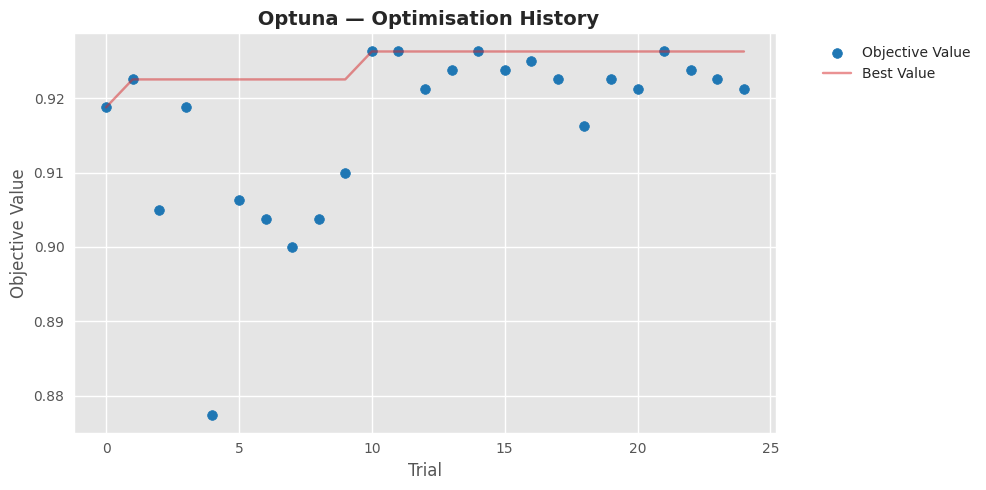

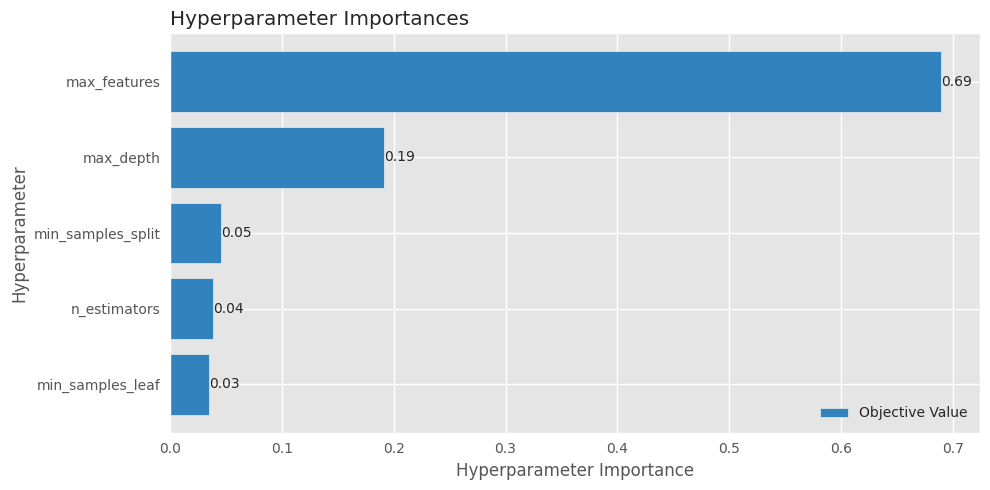


💡 These plots show which hyperparameters had the biggest impact
   on model performance — focus your tuning efforts there!


In [42]:
# ── Optuna Visualisations ──────────────────────────────────────

# 1. Optimisation History — how the best value improves over trials
ax1 = plot_optimization_history(study)
ax1.set_title(" Optuna — Optimisation History", fontsize=14, fontweight="bold")
ax1.figure.set_size_inches(10, 5)
plt.tight_layout()
plt.show()

# 2. Hyperparameter Importances — which hyperparameters mattered most
ax2 = plot_param_importances(study)
ax2.figure.set_size_inches(10, 5)
plt.tight_layout()
plt.show()

print("\n💡 These plots show which hyperparameters had the biggest impact")
print("   on model performance — focus your tuning efforts there!")

### 📊 Method Comparison — All Four Approaches


In [43]:
# ── Build Comparison Table ──────────────────────────────────────
# Get the best scores from each method
best_manual_score = max([float(r["Mean CV Accuracy"].split(" ±")[0]) for r in manual_results])

method_comparison = pd.DataFrame({
    "Method": [
        "❌ Manual Guessing",
        "⚠️ Grid Search CV",
        "⚠️ Random Search CV",
        "✅ Optuna (Bayesian)"
    ],
    "Best CV Accuracy": [
        f"{best_manual_score:.4f}",
        f"{grid_search.best_score_:.4f}",
        f"{random_search.best_score_:.4f}",
        f"{study.best_value:.4f}"
    ],
    "Time (seconds)": [
        f"{time_manual:.2f}s",
        f"{time_grid:.2f}s",
        f"{time_random:.2f}s",
        f"{time_optuna:.2f}s"
    ],
    "Intelligence": [
        "None",
        "Exhaustive but unintelligent",
        "Stochastic sampling",
        "Bayesian (learns from results)"
    ],
    "Scalability": [
        "❌ Poor",
        "❌ Exponential",
        "✅ Good",
        "✅ Excellent"
    ]
})

print("=" * 90)
print("COMPARISON — Hyperparameter Optimisation Methods")
print("=" * 90)
print(method_comparison.to_string(index=False))

COMPARISON — Hyperparameter Optimisation Methods
             Method Best CV Accuracy Time (seconds)                   Intelligence   Scalability
  ❌ Manual Guessing           0.9175          2.08s                           None        ❌ Poor
  ⚠️ Grid Search CV           0.9213          4.57s   Exhaustive but unintelligent ❌ Exponential
⚠️ Random Search CV           0.9188         37.31s            Stochastic sampling        ✅ Good
✅ Optuna (Bayesian)           0.9263        128.82s Bayesian (learns from results)   ✅ Excellent


---

### Summary of the Progression

| Level | Method | Intelligence | Speed | Scalability |
|---|---|---|---|---|
| 1 | Manual Guessing | ❌ None | ❌ Slowest | ❌ Poor |
| 2 | Grid Search CV | ❌ Exhaustive but unintelligent | ⚠️ Exponential growth | ❌ Poor |
| 3 | Random Search CV | ⚠️ Stochastic | ✅ Good | ✅ Good |
| **4** | **Optuna (Bayesian)** | **✅ Learns from results** | **✅ Fast (pruning)** | **✅ Excellent** |

---


---

## 🤖 Section 7 — Auto Model Selection (Optional · Advanced)

> ⚠️ **This section does not run in the browser.** PyCaret depends on
> `lightgbm`, `xgboost`, `catboost`, and `numba` — none of which have a
> WebAssembly build. The code below is **commented out** and paired with its
> **pre-computed output**, so you can follow the idea without running anything.
> To run it for real, see **“Run this locally”** inside the code cell.

### 7a. The Idea

So far we've been optimising **one model** (Random Forest). But what if a completely different model architecture would perform better?

**Auto model selection** = systematically try **multiple model types**, each with their own optimised hyperparameters, and **pick the winner**.

---

### 7b. The Candidate Models

| Model | Key Strength | How It Works |
|---|---|---|
| **XGBoost** | Competition winner, very fast | Gradient boosting — builds trees sequentially, each correcting the previous one's errors |
| **Histogram-based Gradient Boosting (HGBT)** | Scales to large datasets | sklearn's implementation — bins features into histograms for faster training |
| **CatBoost** | Great out-of-the-box performance | Handles categorical features natively, uses ordered boosting to reduce overfitting |

**Key point:** Each model has its *own* set of hyperparameters. Manually tuning each one would be extremely time-consuming.

---

### 7c. PyCaret — Automated Model Comparison

**PyCaret** is an open-source, low-code ML library that wraps scikit-learn, XGBoost, LightGBM, CatBoost, and Optuna behind a **unified API**.

With `compare_models()`, PyCaret trains and evaluates **15-25+ algorithms** with cross-validation in a single function call — then returns a leaderboard ranked by your chosen metric.

> 📝 **Note:** PyCaret requires `pip install pycaret`. The cell below shows the code pattern (commented out) and the **pre-computed output** from a local run.

---

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# OPTIONAL · ADVANCED — does NOT run in the browser.
# (PyCaret needs lightgbm / xgboost / catboost / numba — no WebAssembly build.)
#
# ▶ RUN THIS LOCALLY:
#     1. Download this notebook:  File ▸ Download
#     2. In local Jupyter or Google Colab:  pip install pycaret
#     3. Select every line below, toggle the comments off (Cmd/Ctrl + /), and run.
#
# Expected results are shown in the next cell (pre-computed from a local run).
# ════════════════════════════════════════════════════════════════════════════

# from pycaret.classification import ClassificationExperiment
#
# # Recreate the full DataFrame for PyCaret
# df_pycaret = df.copy()

# print("=" * 70)
# print("AUTO MODEL SELECTION — PyCaret")
# print("=" * 70)

# # Step 1: Setup the experiment
# # PyCaret handles preprocessing, train/test split, and encoding automatically
# exp = ClassificationExperiment()
# exp.setup(
#     data=df_pycaret,
#     target="target",
#     session_id=RANDOM_STATE,
#     normalize=True,
#     fold=5,
#     verbose=False
# )
# print("\n✅ Step 1: Experiment setup complete")

# # Step 2: Compare multiple models automatically
# # This trains and evaluates 15+ algorithms with cross-validation
# print("\n🔄 Step 2: Comparing models... (this may take a few minutes)")
# best_models = exp.compare_models(n_select=3, sort="Accuracy")

# print("\n✅ Step 2: Model comparison complete")
# print("\nTop 3 models selected by PyCaret:")
# for i, model in enumerate(best_models, 1):
#     print(f"  {i}. {type(model).__name__}")

# # Step 3: Tune the best model's hyperparameters
# print("\n🔄 Step 3: Tuning best model hyperparameters...")
# tuned_model = exp.tune_model(best_models[0], n_iter=20, optimize="Accuracy")
# print("✅ Step 3: Tuning complete")

# # Step 4: Finalise — retrain on the full dataset
# print("\n🔄 Step 4: Finalising model (retrain on full dataset)...")
# final_model = exp.finalize_model(tuned_model)
# print("✅ Step 4: Final model ready for deployment!")

# print("\n" + "=" * 70)
# print("🎉 In ~5 lines of code, PyCaret just:")
# print("   • Compared 15+ algorithms with cross-validation")
# print("   • Selected the top 3 performers")
# print("   • Tuned the best model's hyperparameters")
# print("   • Retrained on the full dataset")
# print("   • Gave us a production-ready pipeline")
# print("=" * 70)

### 📋 Expected output (pre-computed from a local run)

Running the cell above locally produces a cross-validated leaderboard from
`compare_models()` — **16 algorithms** ranked by accuracy:

| Model | Accuracy | AUC | Recall | Prec. | F1 | Kappa | MCC | TT (sec) |
|---|---|---|---|---|---|---|---|---|
| **Extra Trees Classifier** ⭐ | **0.9371** | 0.9801 | 0.9346 | 0.9404 | 0.9372 | 0.8743 | 0.8747 | 0.17 |
| **CatBoost Classifier** ⭐ | **0.9371** | 0.9796 | 0.9402 | 0.9356 | 0.9375 | 0.8742 | 0.8749 | 8.96 |
| **Random Forest Classifier** ⭐ | **0.9229** | 0.9732 | 0.9204 | 0.9265 | 0.9230 | 0.8457 | 0.8466 | 0.29 |
| K Neighbors Classifier | 0.9200 | 0.9717 | 0.9147 | 0.9259 | 0.9199 | 0.8400 | 0.8408 | 0.05 |
| Light Gradient Boosting Machine | 0.9186 | 0.9741 | 0.9260 | 0.9144 | 0.9196 | 0.8371 | 0.8382 | 0.15 |
| Extreme Gradient Boosting (XGBoost) | 0.9086 | 0.9685 | 0.9118 | 0.9076 | 0.9091 | 0.8171 | 0.8182 | 0.16 |
| Gradient Boosting Classifier | 0.8971 | 0.9649 | 0.9004 | 0.8961 | 0.8978 | 0.7942 | 0.7951 | 0.56 |
| Quadratic Discriminant Analysis | 0.8714 | 0.9287 | 0.8436 | 0.8952 | 0.8678 | 0.7429 | 0.7452 | 0.03 |
| Ada Boost Classifier | 0.8586 | 0.9294 | 0.8551 | 0.8639 | 0.8589 | 0.7171 | 0.7180 | 0.20 |
| Ridge Classifier | 0.8457 | 0.9137 | 0.8751 | 0.8284 | 0.8510 | 0.6913 | 0.6926 | 0.19 |
| Logistic Regression | 0.8443 | 0.9137 | 0.8610 | 0.8354 | 0.8474 | 0.6885 | 0.6898 | 1.62 |
| Linear Discriminant Analysis | 0.8443 | 0.9138 | 0.8723 | 0.8280 | 0.8494 | 0.6884 | 0.6897 | 0.21 |
| Naive Bayes | 0.8343 | 0.9124 | 0.8296 | 0.8416 | 0.8349 | 0.6685 | 0.6696 | 0.03 |
| Decision Tree Classifier | 0.8157 | 0.8156 | 0.8210 | 0.8142 | 0.8171 | 0.6313 | 0.6321 | 0.05 |
| SVM - Linear Kernel | 0.7757 | 0.8613 | 0.7785 | 0.7781 | 0.7777 | 0.5513 | 0.5522 | 0.04 |
| Dummy Classifier | 0.5029 | 0.5000 | 1.0000 | 0.5029 | 0.6692 | 0.0000 | 0.0000 | 0.03 |

⭐ = top 3 selected (`n_select=3`).

```text
Top 3 models selected by PyCaret:
  1. ExtraTreesClassifier
  2. CatBoostClassifier
  3. RandomForestClassifier
```

`tune_model()` then ran 5-fold CV over 20 hyperparameter candidates on the best
model. Tuned mean accuracy ≈ **0.8957** — here the *original* Extra Trees model
already scored higher, so PyCaret kept it (a useful reminder that tuning doesn't
always beat sensible defaults). `finalize_model()` retrains the winner on the
full dataset, ready for deployment.

> 💡 **Takeaway:** in ~5 lines, PyCaret compared 16 algorithms with cross-validation,
> ranked them, tuned the best, and produced a deployable pipeline.

### 💡 Why PyCaret?

| Without PyCaret | With PyCaret |
|---|---|
| Manually import each model library | One unified API |
| Write separate train/evaluate loops for each model | `compare_models()` — one line |
| Manually implement cross-validation per model | Built-in CV for all models |
| Manually tune each model's hyperparameters | `tune_model()` — one line |
| Hours of boilerplate code | ~5 lines total |

> 🎯 **When to use PyCaret:** Rapid prototyping, model selection, benchmarking. When you need to quickly find which model family works best for your data.

> ⚙️ **When to use Optuna directly:** Production optimisation, fine-grained control, custom objective functions, integration with existing pipelines.

---


---

## 🏁 Section 8 — Recap & Key Takeaways

### The Three Levers of Model Performance

| # | Lever | What It Does | Key Tool |
|---|---|---|---|
| 1 | 🎯 **Feature Selection** | Give the model *better* inputs — drop noise, keep signal | `.feature_importances_`, correlation analysis |
| 2 | ⚙️ **Hyperparameter Optimisation** | Tune *how* the model learns — find the best configuration | Manual → Grid Search → Random Search → **Optuna** |
| 3 | 🤖 **Auto Model Selection** | Try *different* model architectures — don't assume your first choice is best | **PyCaret**, manual comparison |

### The Hierarchy

```
1️⃣  Get your FEATURES right first
     ↓
2️⃣  Then TUNE the model's hyperparameters
     ↓
3️⃣  Then EXPERIMENT with different model architectures
```

### Our Journey Today

```
Baseline Model (default RF, all 20 features)
     ↓
Feature Selection (top 10 features → simpler, equally good)
     ↓
Hyperparameter Optimisation (Optuna → better performance)
     ↓
Auto Model Selection (PyCaret → best architecture found automatically)
```

### 📣 Call to Action

This Jupyter Notebook is yours — go experiment!
- Change the synthetic data parameters
- Try different numbers of features
- Increase the Optuna trial count
- Add your own models to the comparison
- **Break things and learn from it!**

---

*Thank you! Questions?* 🙋

---

## 📚 Further Reading & Resources

### Core Concepts
- **Scikit-learn User Guide** — [scikit-learn.org/stable/user_guide.html](https://scikit-learn.org/stable/user_guide.html) — Comprehensive reference for all models, preprocessing, and evaluation metrics used in this notebook

### Feature Selection
- **Scikit-learn Feature Selection** — [scikit-learn.org/stable/modules/feature_selection.html](https://scikit-learn.org/stable/modules/feature_selection.html) — Univariate selection, recursive feature elimination, and more

### Hyperparameter Optimisation
- **Optuna Documentation** — [optuna.readthedocs.io](https://optuna.readthedocs.io/) — Full guide on studies, samplers (TPE), pruning, and visualisations
- **Optuna GitHub Examples** — [github.com/optuna/optuna-examples](https://github.com/optuna/optuna-examples) — Ready-to-run examples for sklearn, XGBoost, LightGBM, CatBoost, and more
- **Random Search vs Grid Search (Bergstra & Bengio, 2012)** — [jmlr.org/papers/v13/bergstra12a.html](https://jmlr.org/papers/v13/bergstra12a.html) — The foundational paper showing why random search often beats grid search

### Auto Model Selection
- **PyCaret Documentation** — [pycaret.gitbook.io](https://pycaret.gitbook.io/) — Guides for classification, regression, clustering, and time series
- **PyCaret GitHub** — [github.com/pycaret/pycaret](https://github.com/pycaret/pycaret) — Source code, tutorials, and community examples

### Gradient Boosting Models
- **XGBoost Documentation** — [xgboost.readthedocs.io](https://xgboost.readthedocs.io/)
- **CatBoost Documentation** — [catboost.ai/docs](https://catboost.ai/docs/)
- **Histogram-based Gradient Boosting (sklearn)** — [scikit-learn.org/stable/modules/ensemble.html#histogram-based-gradient-boosting](https://scikit-learn.org/stable/modules/ensemble.html#histogram-based-gradient-boosting)

---